# ATTENTION FROM SCRATCH

# CREATE BASIC VECTOR DATA FOR UNDERSTANDING FOR SOME WORDS

In [6]:
# This is the word data we are working with

words = ['dream','big','and','work', 'for', 'it'] # total six words


In [3]:
import torch
# Input vectors corresponding to words 
inputs = torch.tensor([
    [0.73,0.45,0.31], # ====== Dream X1
    [0.75,0.20,0.55],  # ===== big X2
    [0.30,0.80,0.40],  # ===== and X3
    [0.85,0.35,0.60],  # ===== work X4
    [0.55,0.15,0.75],  # ===== for X5
    [0.25,0.20,0.85],  # ===== it X6
])

# Visualize the embedding in 3D

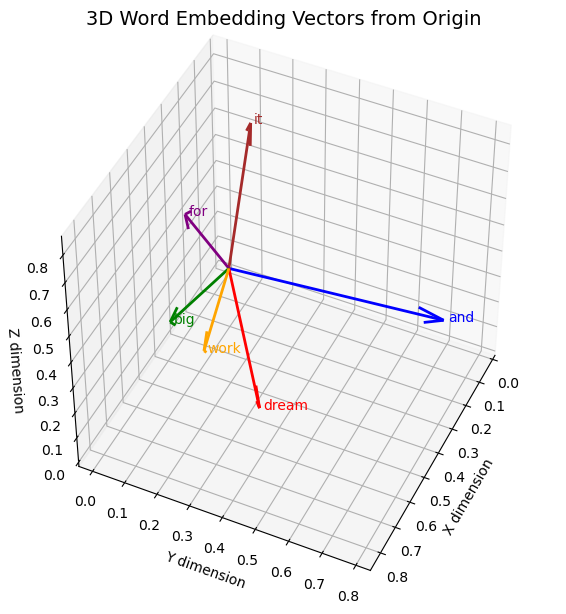

In [3]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np


colors = ["red", "green", "blue", "orange", "purple", "brown"]

# =======================
# 3D Plot with arrows
# =======================
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot each vector as an arrow from origin
for i, (vec, color, word) in enumerate(zip(inputs, colors, words)):
    ax.quiver(
        0, 0, 0,                     # Origin
        vec[0], vec[1], vec[2],      # Vector components
        color=color,
        arrow_length_ratio=0.1,
        linewidth=2,
    )
    ax.text(vec[0]+0.02, vec[1]+0.02, vec[2]+0.02, word, color=color, fontsize=10)

# Axis labels
ax.set_xlabel("X dimension")
ax.set_ylabel("Y dimension")
ax.set_zlabel("Z dimension")
ax.set_title("3D Word Embedding Vectors from Origin", fontsize=14)

# =======================
# Auto-scale axes properly
# =======================
# Include origin so the box includes all arrows
all_points = torch.vstack([inputs, torch.zeros(1, 3)])
x_vals, y_vals, z_vals = all_points[:, 0], all_points[:, 1], all_points[:, 2]

# Determine bounds around all points with small padding
max_range = (x_vals.max() - x_vals.min(),
             y_vals.max() - y_vals.min(),
             z_vals.max() - z_vals.min())
max_range = max(max_range) / 2.0

mid_x = (x_vals.max() + x_vals.min()) / 2
mid_y = (y_vals.max() + y_vals.min()) / 2
mid_z = (z_vals.max() + z_vals.min()) / 2

# Set limits centered at midpoints
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

# Slight zoom-out to fit arrows
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=45, azim=25)  # adjust viewing angle

plt.tight_layout()
plt.show()


# Class for self attention

In [4]:

import torch
import torch.nn as nn

class self_attention(nn.Module):
    def __init__(self,d_in,d_out,qkv_bias=False):
        super().__init__()
        self.w_q = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.w_k = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.w_v = nn.Linear(d_in,d_out,bias=qkv_bias)
        
    def forward(self,x):
        keys = self.w_k(x)
        queries = self.w_q(x)
        values = self.w_v(x)
        attention_scores = queries @ keys.T
        attention_weights = torch.softmax(attention_scores/keys.shape[-1]**0.5,dim=-1)
        context_vec = attention_weights @ values
        return context_vec
        
        

# Apply for our toy example data

In [5]:
d_in = inputs.shape[1] # rows
d_out = 2 # out choice
torch.manual_seed(768)

self_attention = self_attention(d_in,d_out) # call the class that we have defined
print("This is what we got as context vector when we pass out inputs ---> \n")
print(self_attention(inputs))

This is what we got as context vector when we pass out inputs ---> 

tensor([[ 0.1104, -0.0898],
        [ 0.1059, -0.0873],
        [ 0.1122, -0.0885],
        [ 0.1070, -0.0880],
        [ 0.1033, -0.0848],
        [ 0.1024, -0.0830]], grad_fn=<MmBackward0>)


# Final attention weights

In [6]:
queries = self_attention.w_q(inputs)
#print(queries)
print("The shape of the queries is ", queries.shape)

keys = self_attention.w_k(inputs)
#print(keys)
print("The shape of the keys is ", keys.shape)
#print(keys.T)
print("The shape of the keys transposed is ", keys.T.shape)


attn_scores = queries @ keys.T
print("The shape of attention scores  is ", attn_scores.shape)
#print(attn_scores)
attn_weights = torch.softmax(attn_scores/ keys.shape[-1]**0.5, dim = 1)
print("\n")
print("Attention weights after Softmax\n\n",attn_weights)
#print(attn_weights.shape)

The shape of the queries is  torch.Size([6, 2])
The shape of the keys is  torch.Size([6, 2])
The shape of the keys transposed is  torch.Size([2, 6])
The shape of attention scores  is  torch.Size([6, 6])


Attention weights after Softmax

 tensor([[0.1606, 0.1644, 0.1663, 0.1624, 0.1702, 0.1761],
        [0.1648, 0.1627, 0.1743, 0.1617, 0.1655, 0.1709],
        [0.1629, 0.1690, 0.1580, 0.1682, 0.1713, 0.1705],
        [0.1635, 0.1629, 0.1726, 0.1616, 0.1668, 0.1727],
        [0.1692, 0.1635, 0.1764, 0.1639, 0.1625, 0.1646],
        [0.1727, 0.1655, 0.1745, 0.1672, 0.1610, 0.1591]],
       grad_fn=<SoftmaxBackward0>)


In [7]:
# Visualize the attention matrix

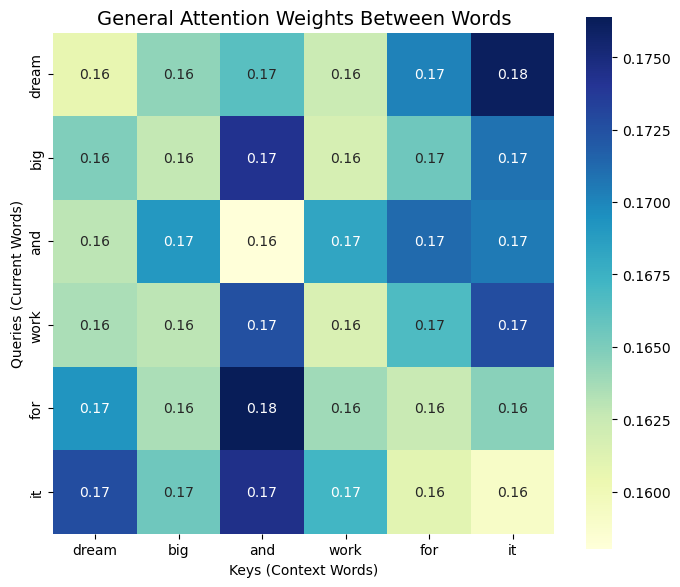

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch


# =============================
# Plot attention weight heatmap
# =============================
plt.figure(figsize=(7, 6))
sns.heatmap(
    attn_weights.detach().numpy(),
    xticklabels=words,
    yticklabels=words,
    annot=True, fmt=".2f",
    cmap="YlGnBu", cbar=True, square=True
)

plt.title("General Attention Weights Between Words", fontsize=14)
plt.xlabel("Keys (Context Words)")
plt.ylabel("Queries (Current Words)")
plt.tight_layout()
plt.show()


# So far we developed generalized attention 
# now we will implement Causal attention

# There are two ways

## 1. Multiply attention weight matrix with a lower trainagular matrix where diagonal above elements are zeros

In [9]:
context_length = attn_weights.shape[0]
print("Context length is ", context_length)
mask_simple = torch.tril(torch.ones(context_length,context_length))
print(mask_simple) # This is the simple mask we are applying

Context length is  6
tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


## Attention weights after applying mask

In [10]:
masked_simple = attn_weights * mask_simple
print(masked_simple)

tensor([[0.1606, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1648, 0.1627, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1629, 0.1690, 0.1580, 0.0000, 0.0000, 0.0000],
        [0.1635, 0.1629, 0.1726, 0.1616, 0.0000, 0.0000],
        [0.1692, 0.1635, 0.1764, 0.1639, 0.1625, 0.0000],
        [0.1727, 0.1655, 0.1745, 0.1672, 0.1610, 0.1591]],
       grad_fn=<MulBackward0>)


## Attention weights normalized 

In [11]:
row_sums = masked_simple.sum(dim=1,keepdim=True)
print(row_sums.shape)

masked_simple_norm = masked_simple/row_sums
print(masked_simple_norm)


torch.Size([6, 1])
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5033, 0.4967, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3325, 0.3450, 0.3225, 0.0000, 0.0000, 0.0000],
        [0.2475, 0.2466, 0.2612, 0.2446, 0.0000, 0.0000],
        [0.2025, 0.1957, 0.2111, 0.1962, 0.1945, 0.0000],
        [0.1727, 0.1655, 0.1745, 0.1672, 0.1610, 0.1591]],
       grad_fn=<DivBackward0>)


In the above matrix we can see that future tokens attention is indeed masked to zero 
to preserve causal relationship.
But there is a catch ................====>

Since we are masking attention weights which we got by applying softmax, which inherently contains future tokens,
Even though we masked future tokens , we still breaking causality inherently.

softmax(xi)= exp(xi) / sum (exp(xi)) , sum runs over all i

# 2. So we do something tricky 
since exp(-inf) ---> 0, we use that information before taking softmax


In [12]:
print(attn_scores)

tensor([[-0.0985, -0.0658, -0.0494, -0.0834, -0.0169,  0.0313],
        [-0.0921, -0.1105, -0.0134, -0.1191, -0.0863, -0.0410],
        [ 0.0119,  0.0637, -0.0314,  0.0569,  0.0823,  0.0763],
        [-0.1009, -0.1060, -0.0247, -0.1179, -0.0730, -0.0234],
        [-0.0360, -0.0847,  0.0226, -0.0814, -0.0934, -0.0756],
        [ 0.0356, -0.0245,  0.0502, -0.0103, -0.0633, -0.0806]],
       grad_fn=<MmBackward0>)


## Upper traingular matrix

In [13]:
mask = torch.triu(torch.ones(context_length,context_length), diagonal=1)
print(mask)

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])


# Now ones are converted to -inf

In [14]:
attn_scores = attn_scores/d_out**0.5
print(attn_scores)

tensor([[-0.0696, -0.0465, -0.0349, -0.0590, -0.0120,  0.0221],
        [-0.0651, -0.0781, -0.0094, -0.0842, -0.0610, -0.0290],
        [ 0.0084,  0.0451, -0.0222,  0.0402,  0.0582,  0.0539],
        [-0.0713, -0.0750, -0.0175, -0.0834, -0.0516, -0.0166],
        [-0.0255, -0.0599,  0.0159, -0.0575, -0.0660, -0.0534],
        [ 0.0252, -0.0173,  0.0355, -0.0073, -0.0447, -0.0570]],
       grad_fn=<DivBackward0>)


In [15]:
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
# mask.bool() function replaces 1 with -inf
print(masked)

tensor([[-0.0696,    -inf,    -inf,    -inf,    -inf,    -inf],
        [-0.0651, -0.0781,    -inf,    -inf,    -inf,    -inf],
        [ 0.0084,  0.0451, -0.0222,    -inf,    -inf,    -inf],
        [-0.0713, -0.0750, -0.0175, -0.0834,    -inf,    -inf],
        [-0.0255, -0.0599,  0.0159, -0.0575, -0.0660,    -inf],
        [ 0.0252, -0.0173,  0.0355, -0.0073, -0.0447, -0.0570]],
       grad_fn=<MaskedFillBackward0>)


# Now take softmax

In [16]:
attn_weights = torch.softmax(masked/keys.shape[-1]**0.5,dim=1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5023, 0.4977, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3328, 0.3415, 0.3257, 0.0000, 0.0000, 0.0000],
        [0.2483, 0.2476, 0.2579, 0.2462, 0.0000, 0.0000],
        [0.2018, 0.1970, 0.2078, 0.1973, 0.1961, 0.0000],
        [0.1709, 0.1659, 0.1722, 0.1670, 0.1627, 0.1613]],
       grad_fn=<SoftmaxBackward0>)


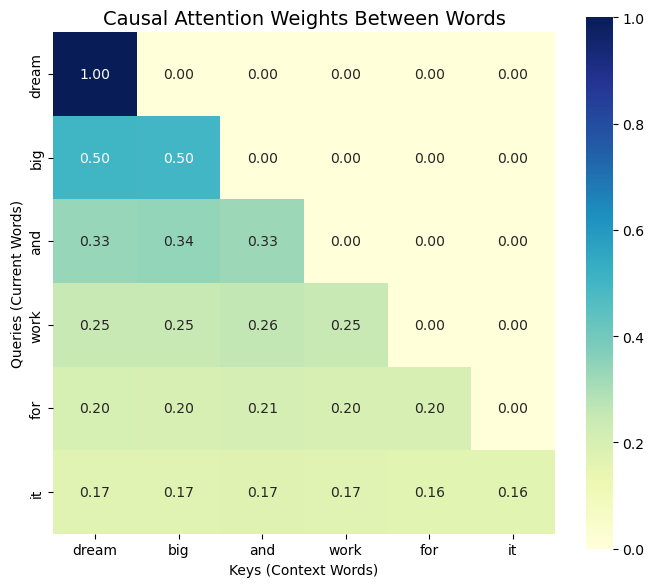

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch


# =============================
# Plot attention weight heatmap
# =============================
plt.figure(figsize=(7, 6))
sns.heatmap(
    attn_weights.detach().numpy(),
    xticklabels=words,
    yticklabels=words,
    annot=True, fmt=".2f",
    cmap="YlGnBu", cbar=True, square=True
)

plt.title("Causal Attention Weights Between Words", fontsize=14)
plt.xlabel("Keys (Context Words)")
plt.ylabel("Queries (Current Words)")
plt.tight_layout()
plt.show()


In [1]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attention(attn, tokens, title="Attention"):
    
    attn = attn.detach().numpy()

    plt.figure(figsize=(6,5))
    plt.imshow(attn, cmap='viridis')

    plt.xticks(range(len(tokens)), tokens)
    plt.yticks(range(len(tokens)), tokens)

    plt.xlabel("Keys")
    plt.ylabel("Queries")
    plt.title(title)

    for i in range(len(tokens)):
        for j in range(len(tokens)):
            plt.text(j, i,
                     f"{attn[i,j]:.2f}",
                     ha='center',
                     va='center',
                     color='white')

    plt.colorbar()
    plt.show()

# MHA 

In [4]:
import torch
import torch.nn.functional as F

torch.manual_seed(0)

d_model = 3
num_heads = 2
head_dim = 2

# Projection matrices for each head
W_Q = torch.randn(num_heads, d_model, head_dim)
W_K = torch.randn(num_heads, d_model, head_dim)
W_V = torch.randn(num_heads, d_model, head_dim)

all_heads = []
all_attentions = []

for h in range(num_heads):

    Q = inputs @ W_Q[h]
    K = inputs @ W_K[h]
    V = inputs @ W_V[h]

    scores = Q @ K.T
    scores = scores / (head_dim ** 0.5)

    attn = F.softmax(scores, dim=-1)

    out = attn @ V

    all_heads.append(out)
    all_attentions.append(attn)

# concatenate heads
final_output = torch.cat(all_heads, dim=-1)

print(final_output.shape)

torch.Size([6, 4])


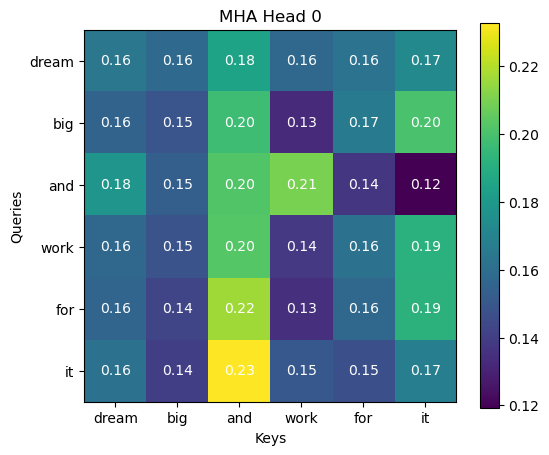

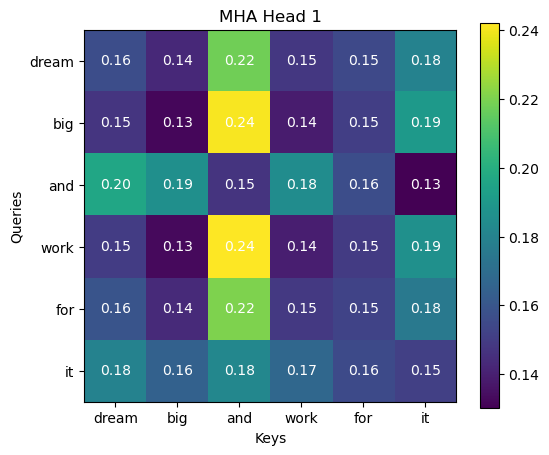

In [7]:
for h, attn in enumerate(all_attentions):
    plot_attention(attn, tokens=words,
                   title=f"MHA Head {h}")

# MQA

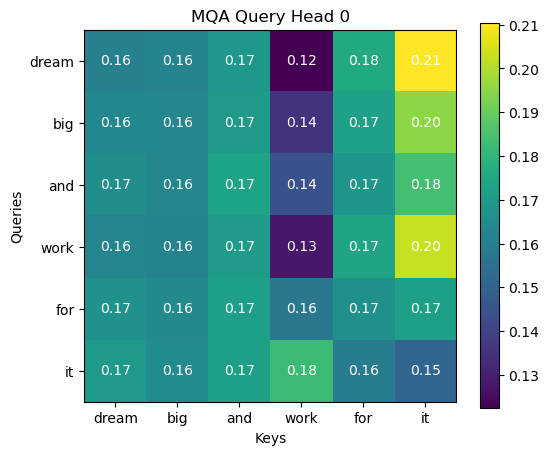

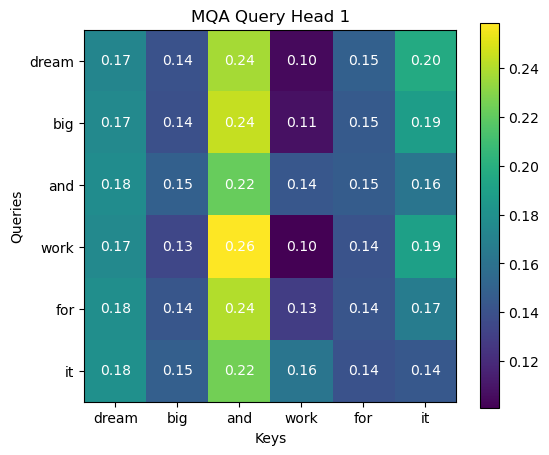

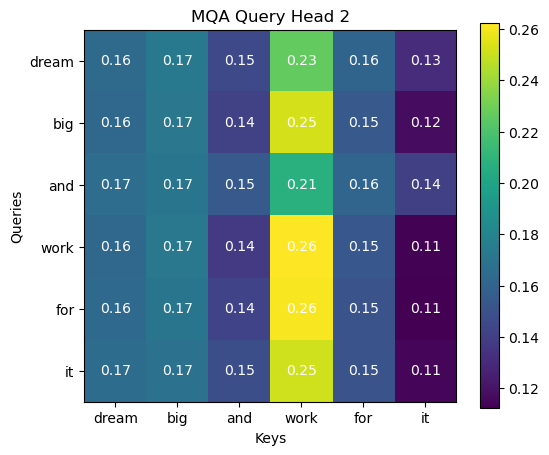

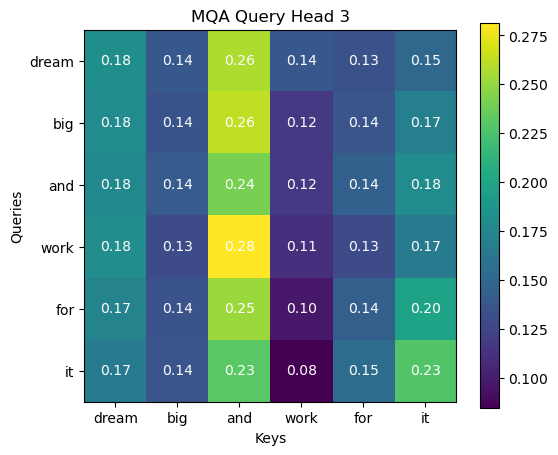

In [9]:
torch.manual_seed(0)

num_heads = 4
head_dim = 2
tokens=words
# Separate Q for each head
W_Q = torch.randn(num_heads, d_model, head_dim)

# Shared K and V
W_K = torch.randn(d_model, head_dim)
W_V = torch.randn(d_model, head_dim)

K = inputs @ W_K
V = inputs @ W_V

mqa_attns = []

for h in range(num_heads):

    Q = inputs @ W_Q[h]

    scores = Q @ K.T
    scores = scores / (head_dim ** 0.5)

    attn = F.softmax(scores, dim=-1)

    mqa_attns.append(attn)

for h, attn in enumerate(mqa_attns):
    plot_attention(attn, tokens,
                   title=f"MQA Query Head {h}")

# GQA

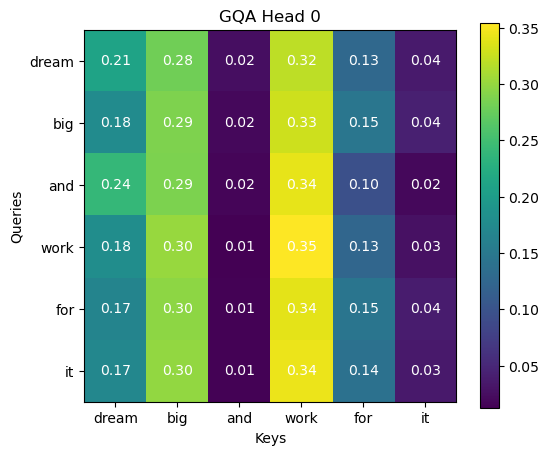

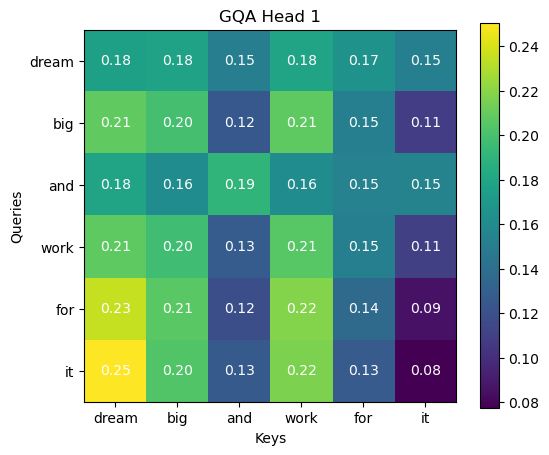

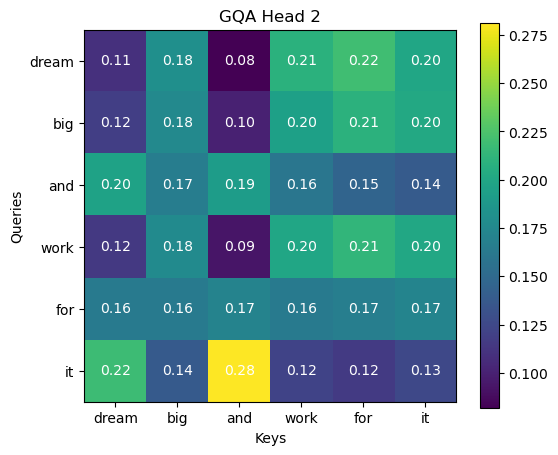

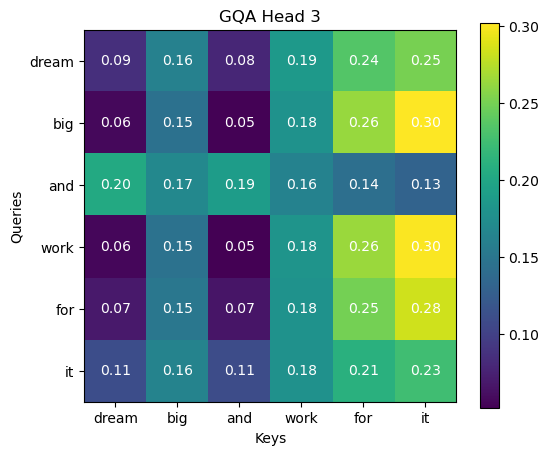

In [10]:
num_heads = 4
num_groups = 2
heads_per_group = num_heads // num_groups

head_dim = 2

W_Q = torch.randn(num_heads, d_model, head_dim)

# Shared per group
W_K = torch.randn(num_groups, d_model, head_dim)
W_V = torch.randn(num_groups, d_model, head_dim)

gqa_attns = []

for h in range(num_heads):

    group_id = h // heads_per_group

    Q = inputs @ W_Q[h]
    K = inputs @ W_K[group_id]
    V = inputs @ W_V[group_id]

    scores = Q @ K.T
    scores /= (head_dim ** 0.5)

    attn = F.softmax(scores, dim=-1)

    gqa_attns.append(attn)

for h, attn in enumerate(gqa_attns):
    plot_attention(attn, tokens,
                   title=f"GQA Head {h}")